In [17]:
import numpy as np
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

In [18]:
unique_labels = [4, 5]  # For clusters 4 and 5
total_clusters = 5  # Assuming you have 5 clusters in total (adjust this based on your dataset)

# Get color for each cluster
colors = [plt.cm.viridis(label / total_clusters) for label in unique_labels]

# Display the colors
for label, color in zip(unique_labels, colors):
    print(f"Cluster {label} color code: {color}")

Cluster 4 color code: (0.477504, 0.821444, 0.318195, 1.0)
Cluster 5 color code: (0.993248, 0.906157, 0.143936, 1.0)


In [19]:
ec_coords = np.genfromtxt('data/GBM39_5k_coordinates.txt')
hsr_coords = np.genfromtxt('data/GBM39HSR_5k_coordinates.txt')

ec_hic = np.load('data/ec_adj_mat_t25.npy')
hsr_hic = np.load('data/hsr_adj_mat_t25.npy')

ec_labels_df = pd.read_csv('outputs/ec_cluster_output.csv')

In [20]:
genes = pd.read_csv('chrom7_genes.csv')
start_loci = 54765000
end_loci = 56050000
genes = genes[((genes['start'] >= start_loci) & (genes['start'] < end_loci)) | 
                       ((genes['end'] >= start_loci) & (genes['end'] < end_loci))]
genes['gene'] = genes['attributes'].str.split(';').str[0].str.split('ID=gene-').str[-1]
genes = genes[['gene', 'start', 'end']]

genes.head()

,gene,start,end
679,SEC61G-DT,54759313,54804969
680,LOC124901636,54806443,54812133
681,LOC105375284,54992419,55018922
682,EGFR,55019017,55211628
683,EGFR-AS1,55179750,55188949


In [21]:
region_loci = ec_labels_df[['node_id', 'start', 'end']]
region_loci.head()

,node_id,start,end
0,0,54765000,54770000
1,1,54770000,54775000
2,2,54775000,54780000
3,3,54780000,54785000
4,4,54785000,54790000


In [22]:
def find_gene(region_start, region_end):
    genes_in_region = genes[
        (genes['start'] <= region_end) & (genes['end'] >= region_start)
    ]['gene'].tolist()
    return ', '.join(genes_in_region) if genes_in_region else 'No Gene'

region_loci['gene'] = ec_labels_df.apply(lambda row: find_gene(row['start'], row['end']), axis=1)

/tmp/ipykernel_248/1710225151.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_loci['gene'] = ec_labels_df.apply(lambda row: find_gene(row['start'], row['end']), axis=1)


In [23]:
region_loci.head()

,node_id,start,end,gene
0,0,54765000,54770000,SEC61G-DT
1,1,54770000,54775000,SEC61G-DT
2,2,54775000,54780000,SEC61G-DT
3,3,54780000,54785000,SEC61G-DT
4,4,54785000,54790000,SEC61G-DT


In [24]:
to_filter = 90
thres = np.percentile(ec_hic, to_filter)
vis_ec = ec_hic.copy()
vis_ec[vis_ec < thres] = 0
vis_ec[vis_ec > 0] = 1

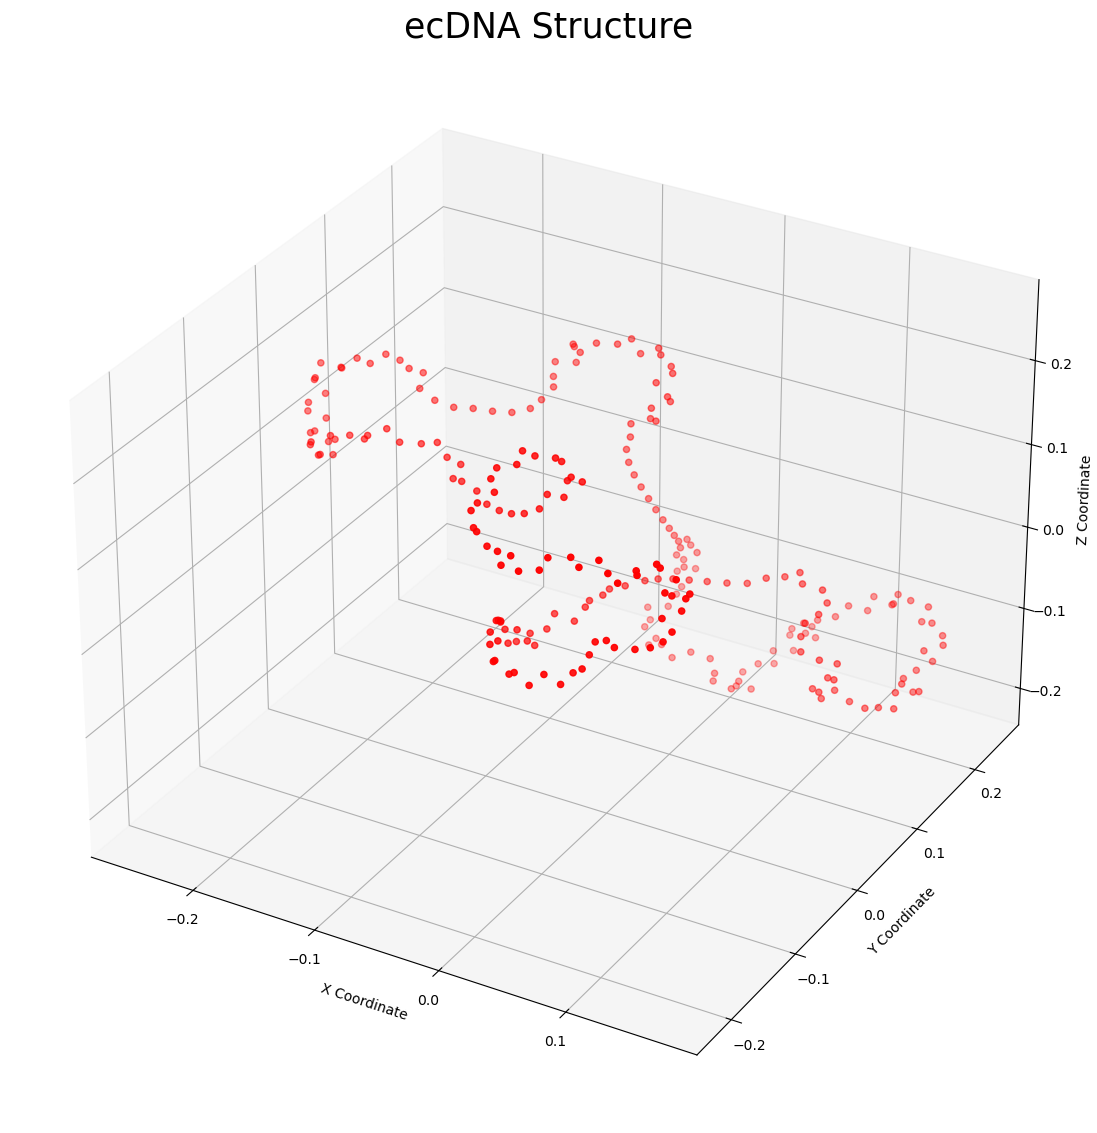

In [25]:
# Extract x, y, z columns
x = ec_coords[:, 0]
y = ec_coords[:, 1]
z = ec_coords[:, 2]

# Create a 3D plot
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='red', marker='o')

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

plt.title('ecDNA Structure', fontsize=25)
plt.savefig('images/ec_structure.png')
plt.show()


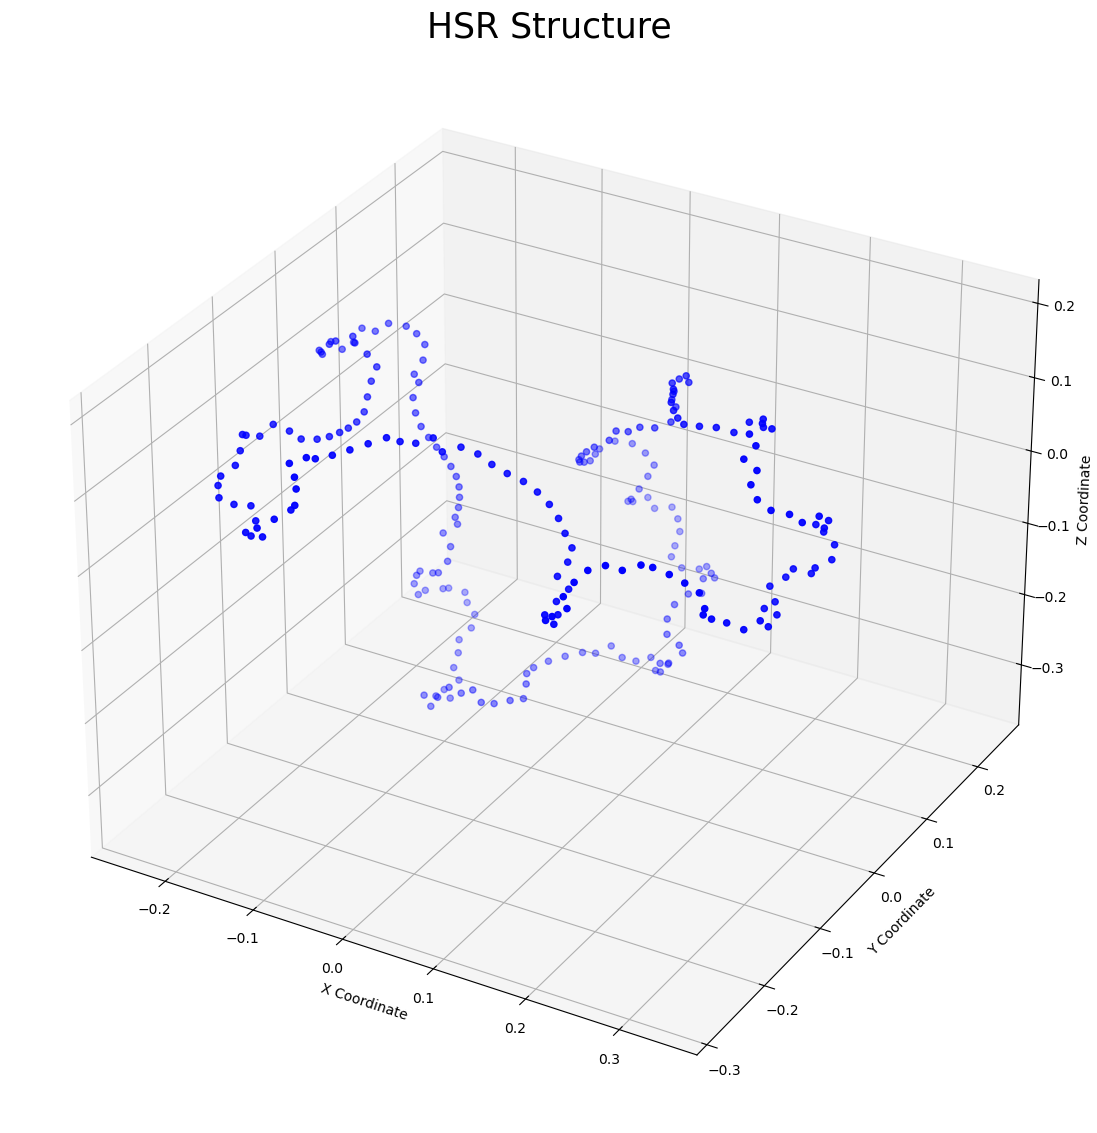

In [26]:
x = hsr_coords[:, 0]
y = hsr_coords[:, 1]
z = hsr_coords[:, 2]

# Create a 3D plot
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='blue', marker='o')

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

plt.title('HSR Structure', fontsize=25)
plt.savefig('images/hsr_structure.png')
plt.show()

/tmp/ipykernel_248/1307656122.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('rainbow', len(unique_genes))  # Get colormap


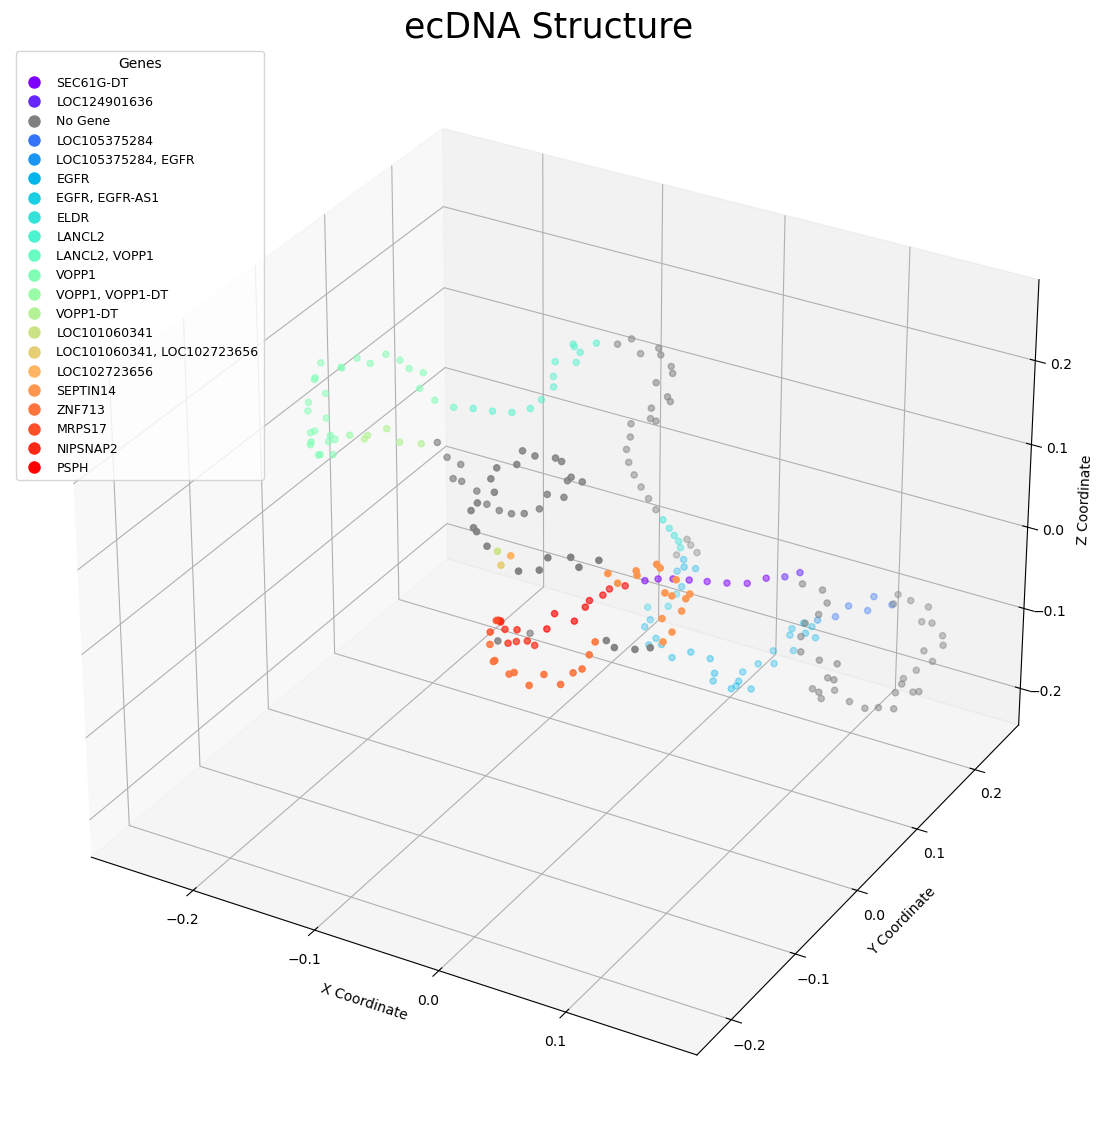

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Extract x, y, z coordinates
x = ec_coords[:, 0]
y = ec_coords[:, 1]
z = ec_coords[:, 2]

df = region_loci.copy()

# Get unique genes and assign colors
unique_genes = df['gene'].unique()  # Updated to region_loci
cmap = plt.cm.get_cmap('rainbow', len(unique_genes))  # Get colormap

# Convert colormap colors to hex
gene_color_map = {gene: mcolors.to_hex(cmap(i)) for i, gene in enumerate(unique_genes)}
gene_color_map['No Gene'] = 'gray'  # Ensure 'No Gene' is gray

# Map colors to the genes in the dataframe
region_colors = [gene_color_map[gene] for gene in df['gene']]

# Create a 3D plot
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with color mapping
sc = ax.scatter(x, y, z, c=region_colors, marker='o')

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
plt.title('ecDNA Structure', fontsize=25)

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=gene_color_map[gene], markersize=10) 
           for gene in unique_genes]
ax.legend(handles, unique_genes, title="Genes", loc='upper left', fontsize=9)

plt.savefig('images/ec_structure_genes.png')
plt.show()

/tmp/ipykernel_248/4223492387.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('rainbow', len(selected_genes))  # Get colormap for selected genes


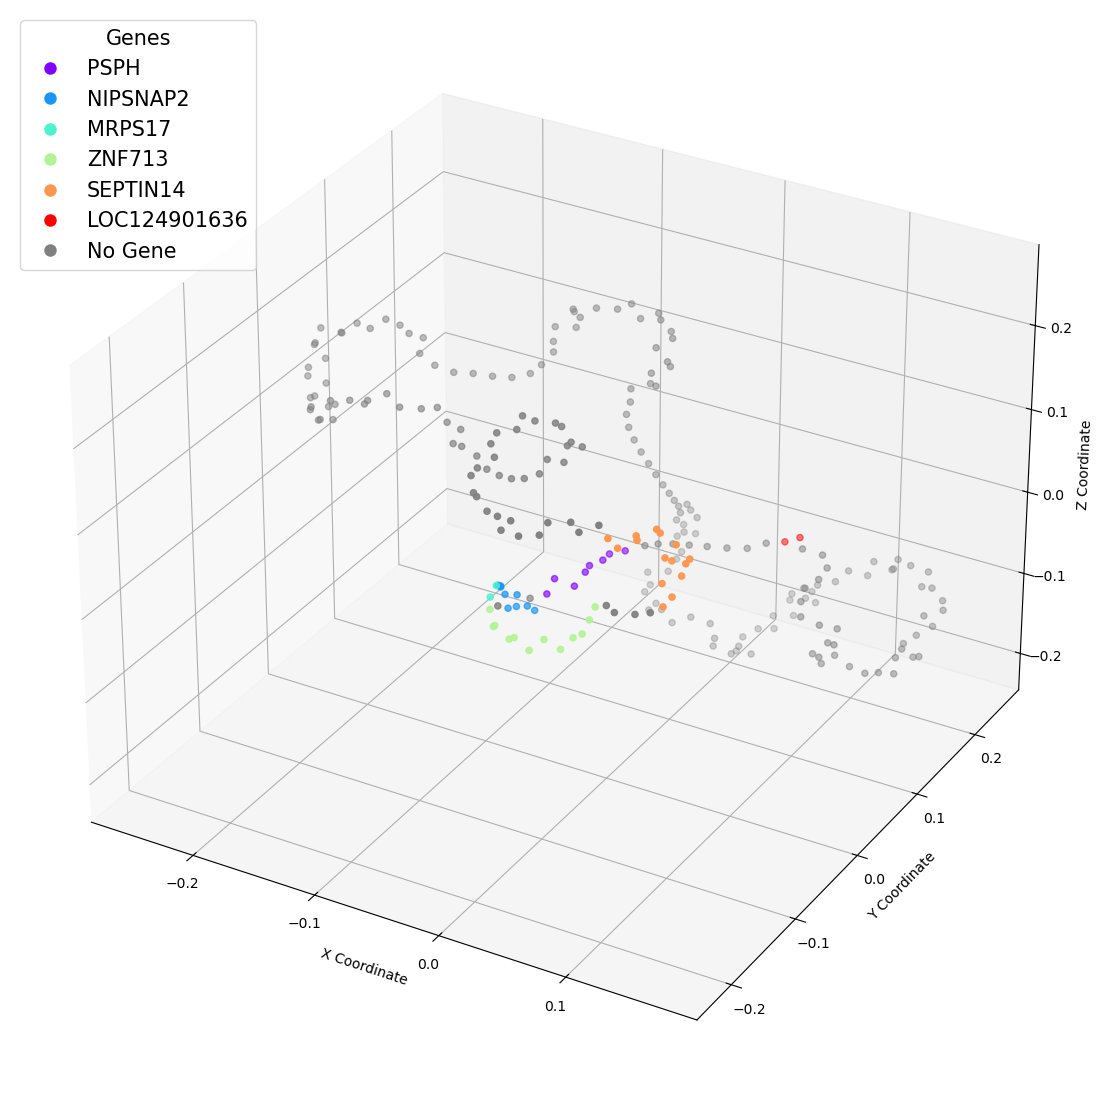

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

# Extract coordinates
x = ec_coords[:, 0]
y = ec_coords[:, 1]
z = ec_coords[:, 2]

# Filter the dataframe for specific genes
selected_genes = ['PSPH', 'NIPSNAP2', 'MRPS17', 'ZNF713', 'SEPTIN14', 'LOC124901636']
df = region_loci.copy()
df['gene'] = df['gene'].apply(lambda g: g if g in selected_genes else 'No Gene')  # Ensure only selected genes have colors

# Get unique genes (including "No Gene")
unique_genes = df['gene'].unique()

# Create colormap
cmap = plt.cm.get_cmap('rainbow', len(selected_genes))  # Get colormap for selected genes
gene_color_map = {gene: mcolors.to_hex(cmap(i)) for i, gene in enumerate(selected_genes)}
gene_color_map['No Gene'] = 'gray'  # Everything else is gray

# Assign colors to all points based on the gene
region_colors = [gene_color_map[df.loc[df.index[i], 'gene']] if i in df.index else 'gray' for i in range(len(x))]

# Create a 3D plot
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with color mapping
sc = ax.scatter(x, y, z, c=region_colors, marker='o')

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Create legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=gene_color_map[gene], markersize=10) 
           for gene in selected_genes] + \
          [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10)]  # Add gray to legend

ax.legend(handles, selected_genes + ['No Gene'], title="Genes", loc='upper left', fontsize=15, title_fontsize=15)
plt.savefig('images/ec_structure_selected_genes.png')
plt.show()

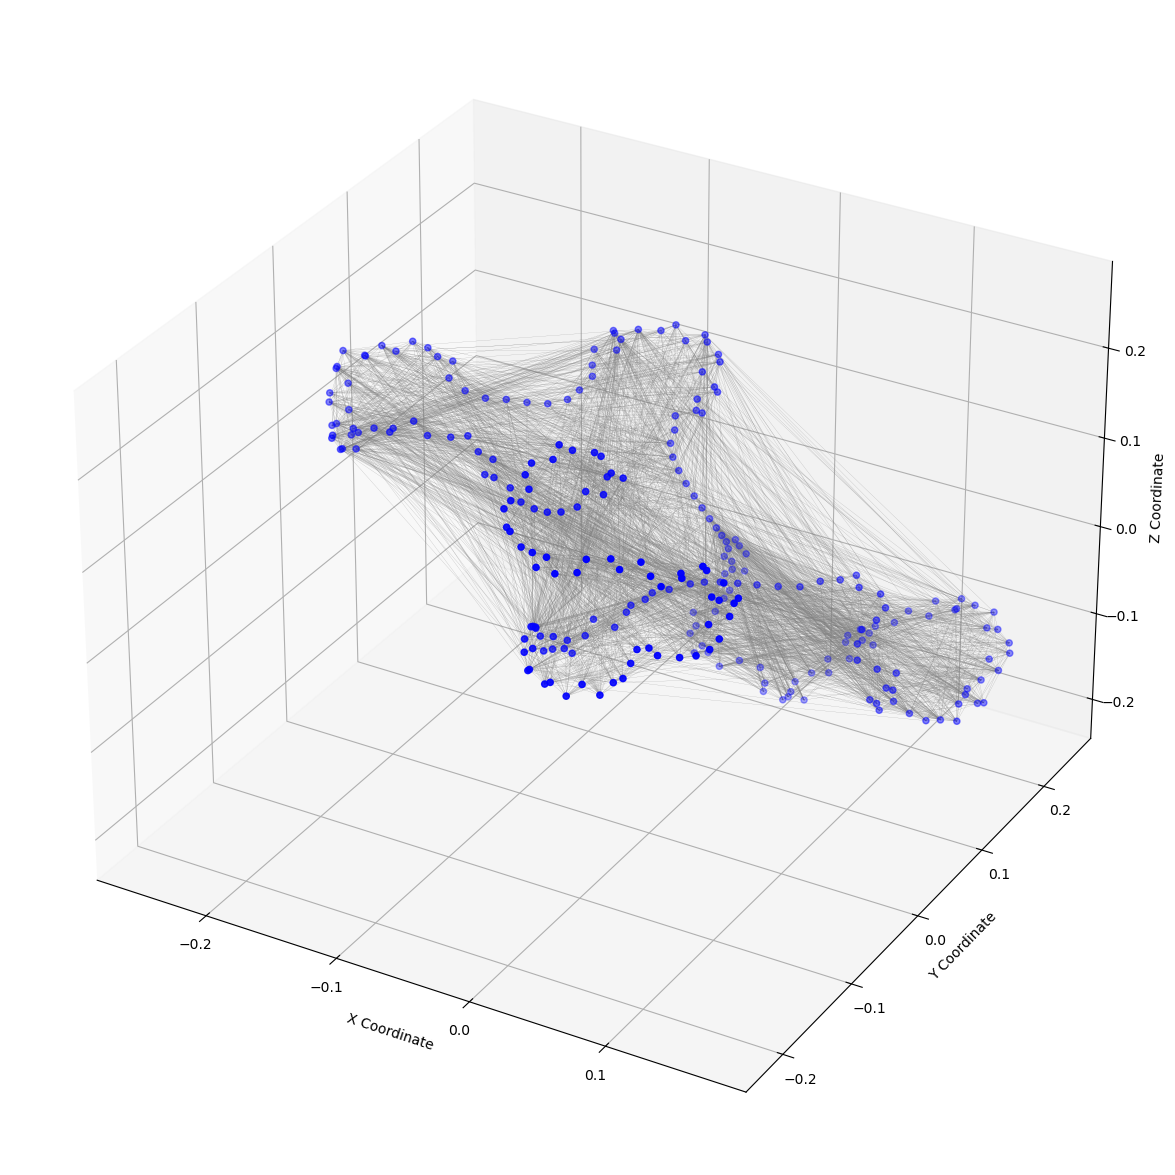

In [29]:
x = ec_coords[:, 0]
y = ec_coords[:, 1]
z = ec_coords[:, 2]

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='blue', marker='o')

num_points = len(x)
for i in range(num_points):
    for j in range(i + 1, num_points):
        if vis_ec[i, j] != 0:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='gray', linewidth=0.1)

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Show plot
plt.show()

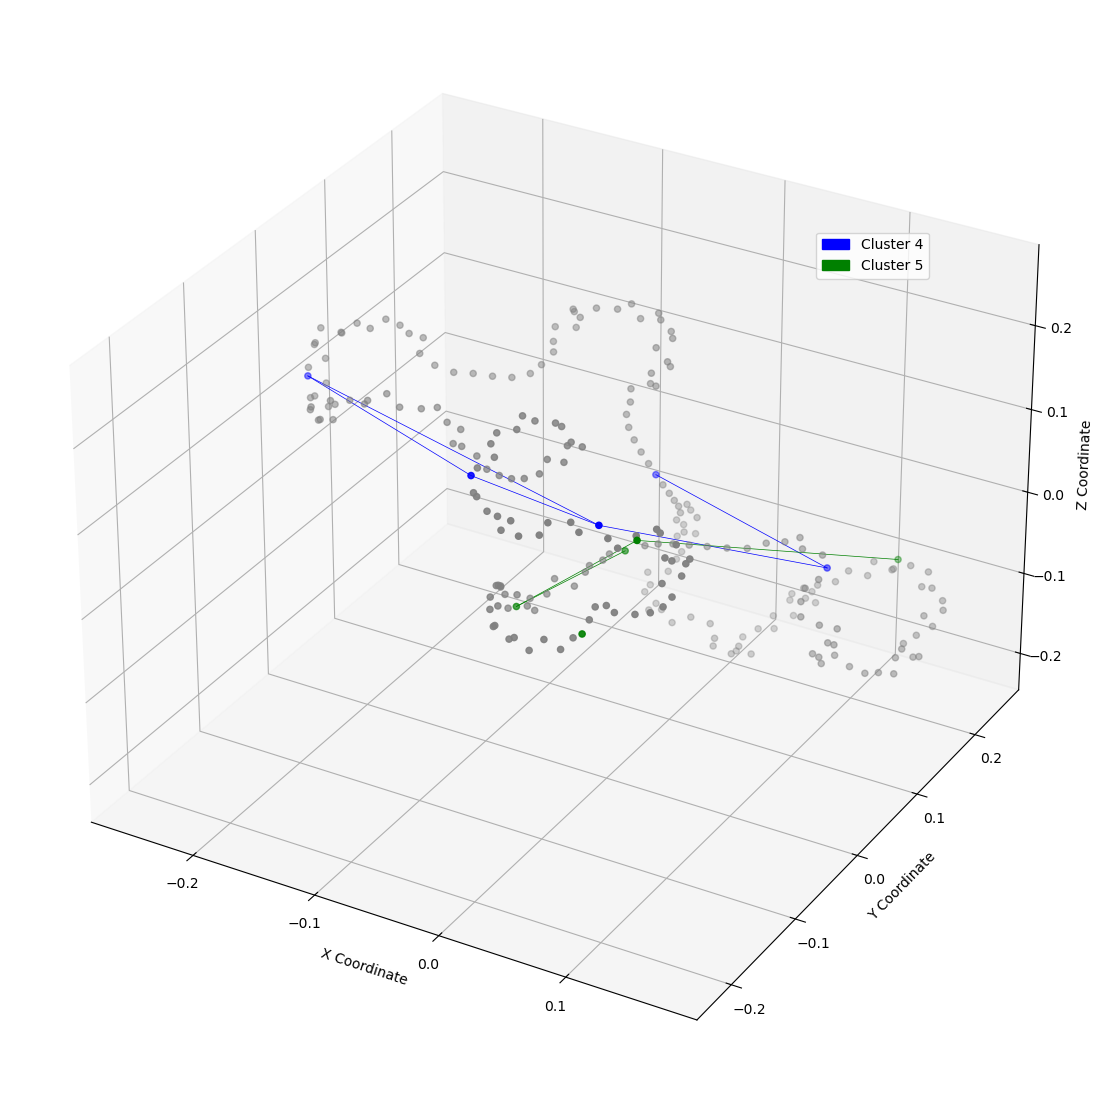

In [30]:
clusters = ec_labels_df['DB_labels']

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

conditions = [clusters == 4, clusters == 5]
choices = ['blue', 'green']

point_colors = np.select(conditions, choices, default='gray')

ax.scatter(x, y, z, c=point_colors, marker='o')

num_points = len(x)
for i in range(num_points):
    for j in range(i + 1, num_points):
        if ec_hic[i, j] != 0 and clusters[i] == 4 and clusters[j] == 4:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='blue', linewidth=0.5)
        if ec_hic[i, j] != 0 and clusters[i] == 5 and clusters[j] == 5:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='green', linewidth=0.5)

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

blue_patch = mpatches.Patch(color='blue', label='Cluster 4')
magenta_patch = mpatches.Patch(color='green', label='Cluster 5')
ax.legend(handles=[blue_patch, magenta_patch], loc='upper center', bbox_to_anchor=(0.8, 0.8))

# Show plot
plt.savefig('images/selected_clusters_graph_3d.png')
plt.show()

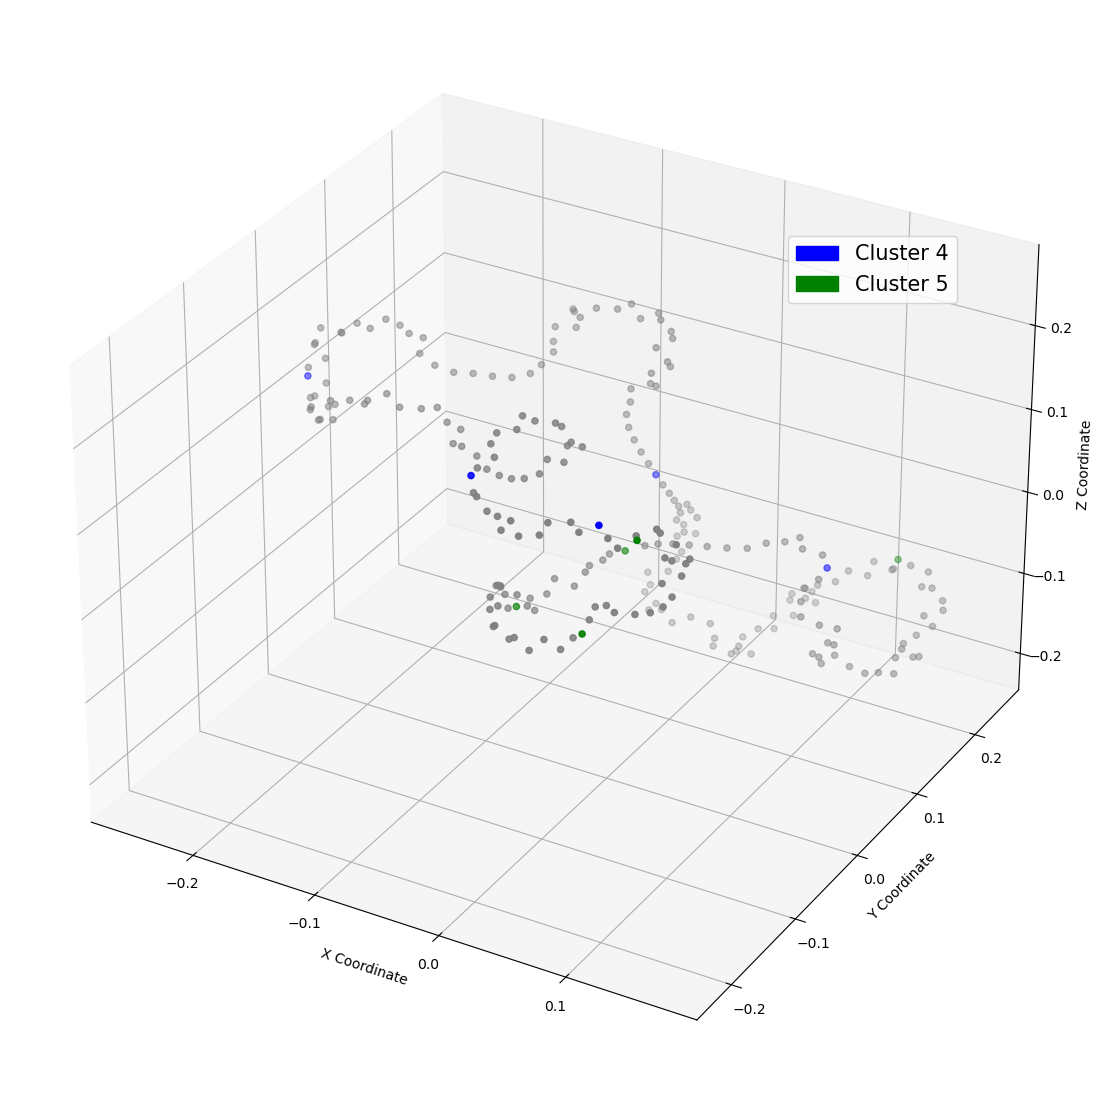

In [34]:
clusters = ec_labels_df['DB_labels']

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

conditions = [clusters == 4, clusters == 5]
choices = ['blue', 'green']

point_colors = np.select(conditions, choices, default='gray')

ax.scatter(x, y, z, c=point_colors, marker='o')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

blue_patch = mpatches.Patch(color='blue', label='Cluster 4')
magenta_patch = mpatches.Patch(color='green', label='Cluster 5')
ax.legend(handles=[blue_patch, magenta_patch], loc='upper center', bbox_to_anchor=(0.8, 0.8), fontsize=15)

# Show plot
plt.savefig('images/selected_clusters_3d.png')
plt.show()

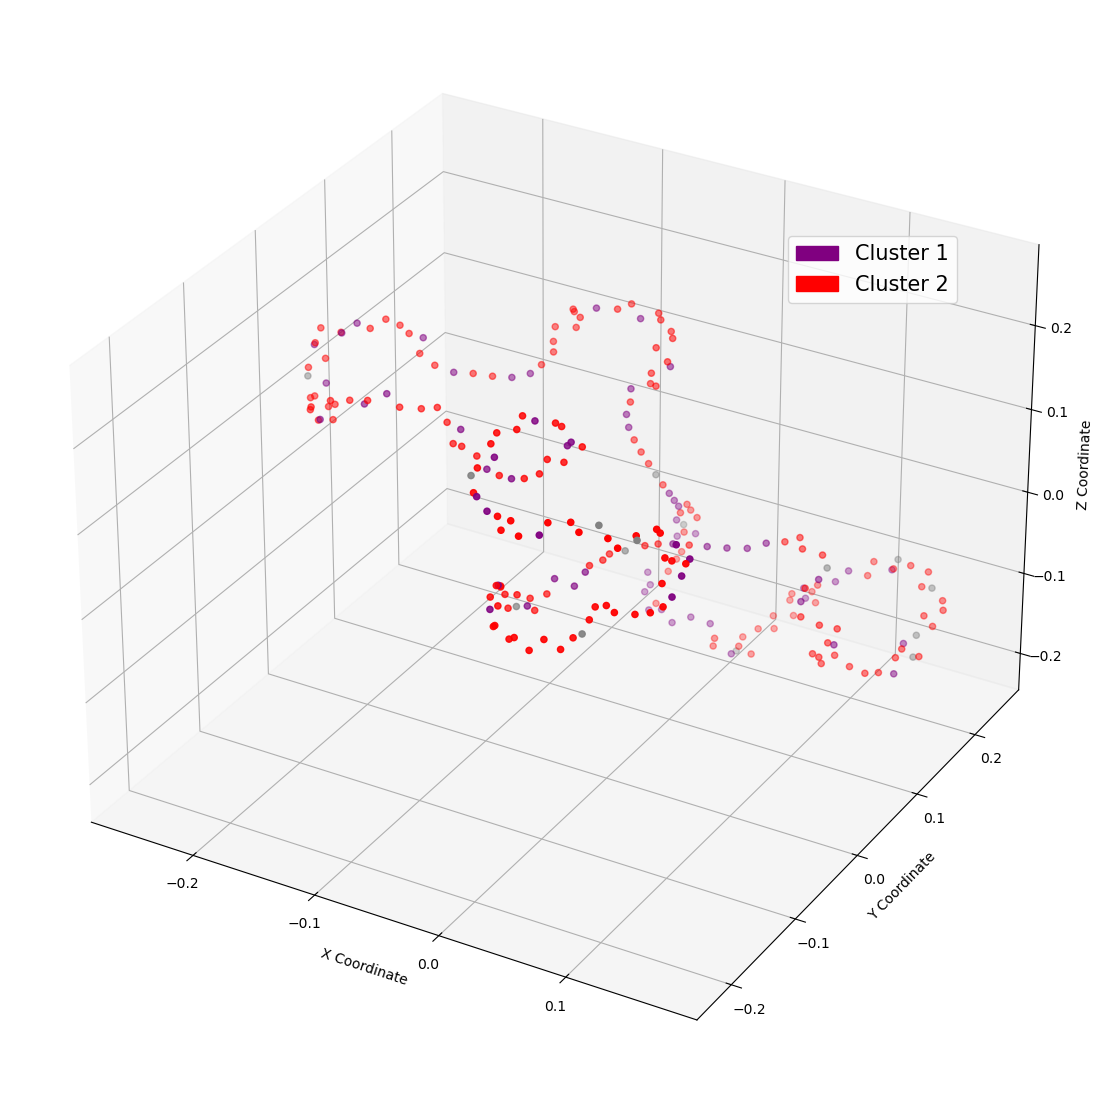

In [35]:
clusters = ec_labels_df['DB_labels']

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(111, projection='3d')

conditions = [clusters == 1, clusters == 2]
choices = ['purple', 'red']

point_colors = np.select(conditions, choices, default='gray')

ax.scatter(x, y, z, c=point_colors, marker='o')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

blue_patch = mpatches.Patch(color='purple', label='Cluster 1')
magenta_patch = mpatches.Patch(color='red', label='Cluster 2')
ax.legend(handles=[blue_patch, magenta_patch], loc='upper center', bbox_to_anchor=(0.8, 0.8), fontsize=15)

# Show plot
plt.savefig('images/selected_clusters_outliers_core_3d.png')
plt.show()

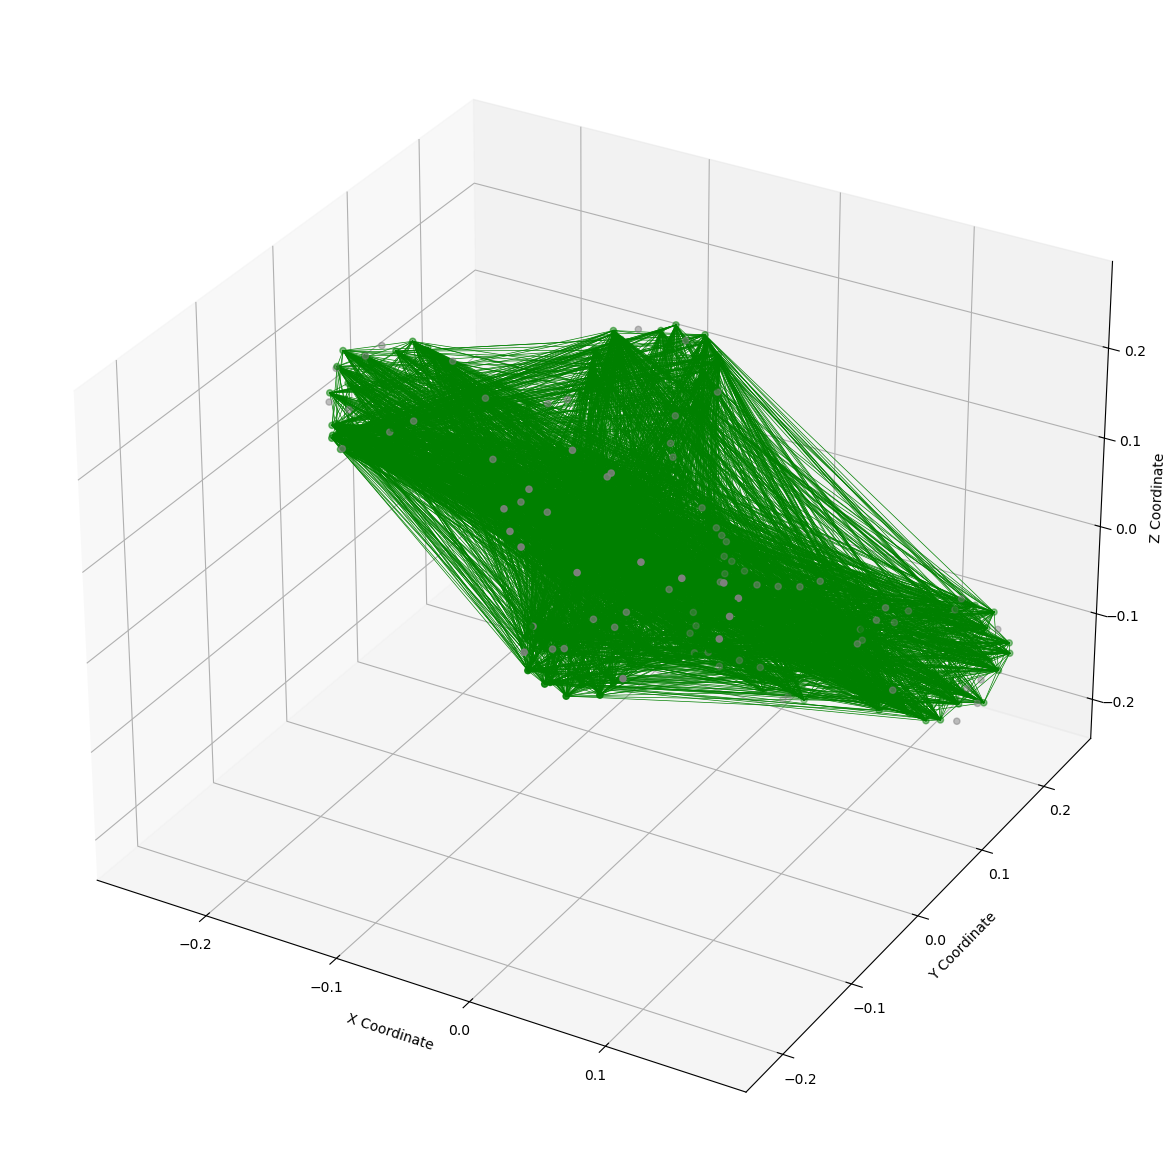

In [33]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

point_colors = np.where(clusters == 2, 'green', 'gray')

ax.scatter(x, y, z, c=point_colors, marker='o')

num_points = len(x)
for i in range(num_points):
    for j in range(i + 1, num_points):
        if ec_hic[i, j] != 0 and clusters[i] == 2 and clusters[j] == 2:
            ax.plot([x[i], x[j]], [y[i], y[j]], [z[i], z[j]], c='green', linewidth=0.5)

# Set plot labels
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')

# Show plot
plt.show()